#Sử Dụng Mô Hình Lai LSTM + XGBOOST

##1. Các thư viện cần thiết

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.3 MB/s eta 0:00:00


In [ ]:
# 1. IMPORT THƯ VIỆN


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime
import re

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, acf, pacf, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.outliers_influence import variance_inflation_factor

import pmdarima as pm

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping

import joblib as jb

from google.colab import drive
drive.mount('/content/drive')

pd.options.display.float_format = '{:,.2f}'.format

import warnings
warnings.filterwarnings('ignore')



Mounted at /content/drive


##2. Thu thập data

In [ ]:
# 2. MOUNT GOOGLE DRIVE

drive.mount('/content/drive')

folder_path = '/content/drive/My Drive/N1-DB/'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
stock = {}
stock['FPT'] = pd.read_csv(
    '/content/' + 'FPT Corp Stock Price History.csv',
    delimiter=';' # Changed delimiter from ',' to ';'
)

for key, df in stock.items():
    print(f"\n===== {key} =====")
    print(df.head())
    print(df.tail())
    print(df.info())


===== FPT =====
         Date      Price       Open       High        Low    Vol. Change %
0  02/03/2026  104,000.0  104,900.0  105,400.0  102,900.0   6.53M   -0.29%
1  02/02/2026  104,300.0  103,300.0  104,300.0  101,600.0   9.33M   -0.19%
2  01/30/2026  104,500.0  106,400.0  106,400.0  103,900.0  10.83M   -1.51%
3  01/29/2026  106,100.0  105,000.0  107,200.0  103,700.0  14.25M    1.53%
4  01/28/2026  104,500.0  102,400.0  105,800.0  102,300.0  11.95M    2.35%
            Date    Price     Open     High      Low   Vol. Change %
2478  03/08/2016  8,948.2  9,060.1  9,078.7  8,948.2  4.60M   -1.23%
2479  03/07/2016  9,060.1  9,134.6  9,209.2  9,060.1  2.96M   -0.82%
2480  03/04/2016  9,134.6  9,060.1  9,190.6  9,060.1  3.46M    0.41%
2481  03/03/2016  9,097.3  9,116.0  9,190.6  9,097.3  3.36M    0.21%
2482  03/02/2016  9,078.7  9,022.8  9,097.3  9,004.1  3.28M    1.04%
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2483 entries, 0 to 2482
Data columns (total 7 columns):
 #   Column  

##3. Tiền xử lý data

In [ ]:
# 4. CHUẨN HÓA DATE

for key, df in stock.items():

    # Reset index if 'Date' is already the index
    if 'Date' not in df.columns and df.index.name == 'Date':
        df = df.reset_index()

    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    df = df.drop_duplicates(subset='Date')

    stock[key] = df

In [ ]:
# 5. TẠO CALENDAR DATE RANGE

full_date_range = pd.date_range(
    start='2016-02-03',
    end='2026-02-03',
    freq='D'
)

print("Tổng số ngày calendar:", len(full_date_range))

Tổng số ngày calendar: 3654


In [ ]:
# 6. THÊM NGÀY THIẾU

def transform_date(df):

    df = df.copy()

    missing_dates = full_date_range.difference(df['Date'])

    missing_df = pd.DataFrame({'Date': missing_dates})

    df = pd.concat([df, missing_df], ignore_index=True)

    df['Date'] = pd.to_datetime(df['Date'])

    df = df.sort_values(by='Date').reset_index(drop=True)

    return df


for key in stock.keys():

    stock[key] = transform_date(stock[key])

    print(f"\nSau khi thêm ngày thiếu: {key}")
    print(stock[key].info())
    print(stock[key].isnull().sum())



Sau khi thêm ngày thiếu: FPT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3654 entries, 0 to 3653
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      3654 non-null   datetime64[ns]
 1   Price     2483 non-null   object        
 2   Open      2483 non-null   object        
 3   High      2483 non-null   object        
 4   Low       2483 non-null   object        
 5   Vol.      2483 non-null   object        
 6   Change %  2483 non-null   object        
dtypes: datetime64[ns](1), object(6)
memory usage: 200.0+ KB
None
Date           0
Price       1171
Open        1171
High        1171
Low         1171
Vol.        1171
Change %    1171
dtype: int64


In [ ]:
# Kiểm tra giá trị thiếu
print("===== KIỂM TRA GIÁ TRỊ THIẾU =====")
print(df.isnull().sum())
print(f"\nTổng số giá trị thiếu: {df.isnull().sum().sum()}")

===== KIỂM TRA GIÁ TRỊ THIẾU =====
Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

Tổng số giá trị thiếu: 0


In [ ]:
# 7. CHUYỂN PRICE TỪ STRING → FLOAT

for key, df in stock.items():

    df['Price'] = (
        df['Price']
        .astype(str)
        .str.replace(',', '', regex=False)
    )

    df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

    stock[key] = df



In [ ]:
# 8. LOẠI BỎ CỘT KHÔNG CẦN

for key, df in stock.items():

    df.drop(
        columns=['Vol.', 'Change %', 'Open', 'High', 'Low'],
        inplace=True,
        errors='ignore'
    )

    stock[key] = df

    print(f"\nSau khi drop column: {key}")
    print(df.head())




Sau khi drop column: FPT
        Date  Price
0 2016-02-03    NaN
1 2016-02-04    NaN
2 2016-02-05    NaN
3 2016-02-06    NaN
4 2016-02-07    NaN


In [ ]:
# 9. SET DATE LÀ INDEX TIME SERIES

for key, df in stock.items():

    df = df.set_index('Date')

    stock[key] = df

In [ ]:
# 10. INTERPOLATE ĐỂ LIÊN TỤC DỮ LIỆU

for key, df in stock.items():

    numeric_cols = df.select_dtypes(include=[np.number]).columns

    df[numeric_cols] = df[numeric_cols].interpolate(
        method='time'
    )

    stock[key] = df

    print(f"\nSau khi nội suy: {key}")
    print(df.info())
    print(df.head())



Sau khi nội suy: FPT
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3654 entries, 2016-02-03 to 2026-02-03
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   3626 non-null   float64
dtypes: float64(1)
memory usage: 57.1 KB
None
            Price
Date             
2016-02-03    NaN
2016-02-04    NaN
2016-02-05    NaN
2016-02-06    NaN
2016-02-07    NaN


##4. EDA


===== TIME SERIES DECOMPOSITION =====
Phân tích chuỗi: Price
Chu kỳ: 252 ngày (~12 tháng giao dịch)


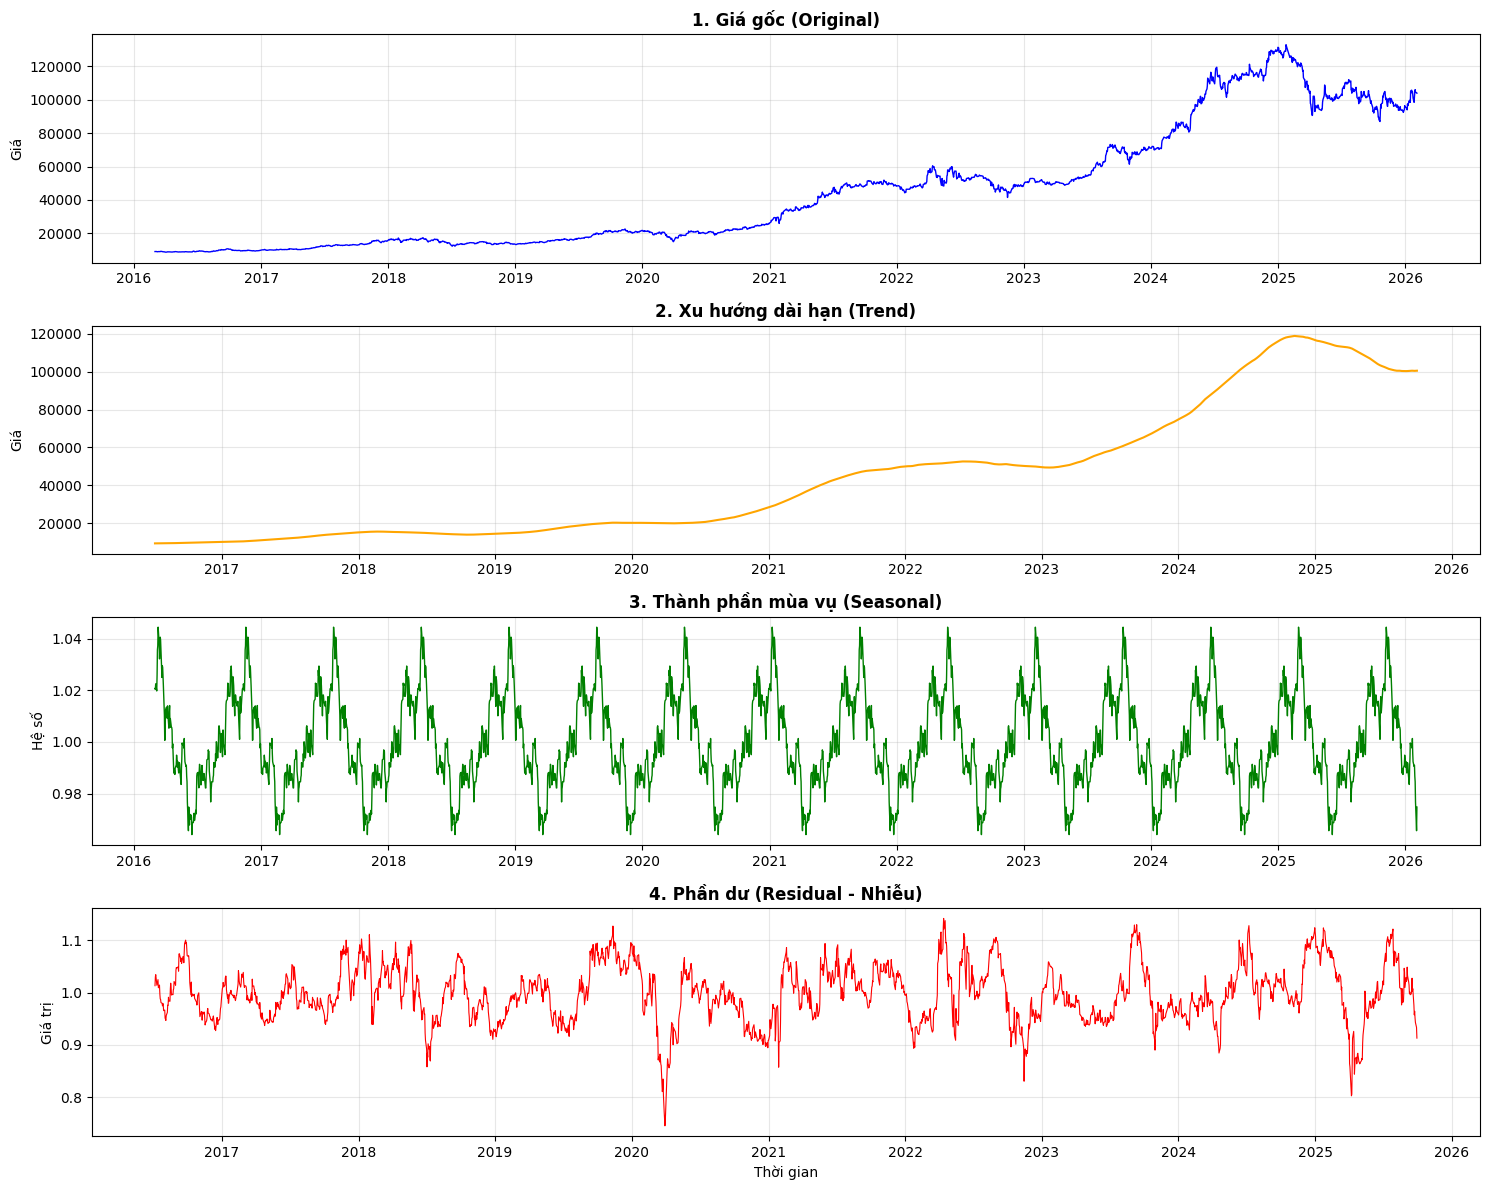


===== THỐNG KÊ CÁC THÀNH PHẦN =====
Phương sai giá gốc: 1248151295.62

Đóng góp vào biến động giá:
  - Xu hướng (Trend): 92.1%
  - Mùa vụ (Seasonal): 0.0%
  - Nhiễu (Residual): 0.0%

✅ Residual thấp (<10%) → Mô hình dự báo tốt có thể đạt độ chính xác cao


In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

def decompose_time_series(df, column='Price', period=252):
    """
    Phân tách chuỗi thời gian thành 3 thành phần:
    - Trend (Xu hướng dài hạn)
    - Seasonal (Mùa vụ)
    - Residual (Phần dư - nhiễu)
    """
    print("\n===== TIME SERIES DECOMPOSITION =====")
    print(f"Phân tích chuỗi: {column}")
    print(f"Chu kỳ: {period} ngày (~12 tháng giao dịch)")

    # Lấy dữ liệu
    series = df[column].dropna()

    # Thực hiện phân tách
    decomposition = seasonal_decompose(series, model='multiplicative', period=period)

    # Vẽ kết quả
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))

    # Original
    axes[0].plot(series.index, series, color='blue', linewidth=1)
    axes[0].set_title('1. Giá gốc (Original)', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Giá')
    axes[0].grid(True, alpha=0.3)

    # Trend
    axes[1].plot(decomposition.trend.index, decomposition.trend, color='orange', linewidth=1.5)
    axes[1].set_title('2. Xu hướng dài hạn (Trend)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Giá')
    axes[1].grid(True, alpha=0.3)

    # Seasonal
    axes[2].plot(decomposition.seasonal.index, decomposition.seasonal, color='green', linewidth=1)
    axes[2].set_title('3. Thành phần mùa vụ (Seasonal)', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Hệ số')
    axes[2].grid(True, alpha=0.3)

    # Residual
    axes[3].plot(decomposition.resid.index, decomposition.resid, color='red', linewidth=0.8)
    axes[3].set_title('4. Phần dư (Residual - Nhiễu)', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('Giá trị')
    axes[3].set_xlabel('Thời gian')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Phân tích thống kê
    print("\n===== THỐNG KÊ CÁC THÀNH PHẦN =====")

    # Tính đóng góp của từng thành phần
    total_var = series.var()
    trend_var = decomposition.trend.var()
    seasonal_var = decomposition.seasonal.var()
    resid_var = decomposition.resid.var()

    print(f"Phương sai giá gốc: {total_var:.2f}")
    print(f"\nĐóng góp vào biến động giá:")
    print(f"  - Xu hướng (Trend): {trend_var/total_var*100:.1f}%")
    print(f"  - Mùa vụ (Seasonal): {seasonal_var/total_var*100:.1f}%")
    print(f"  - Nhiễu (Residual): {resid_var/total_var*100:.1f}%")

    if resid_var/total_var < 0.1:
        print("\n✅ Residual thấp (<10%) → Mô hình dự báo tốt có thể đạt độ chính xác cao")
    elif resid_var/total_var > 0.3:
        print("\n⚠️ Residual cao (>30%) → Giá có nhiễu lớn, khó dự báo chính xác")

    return decomposition

# Áp dụng
decomposition = decompose_time_series(df, 'Price', period=252)

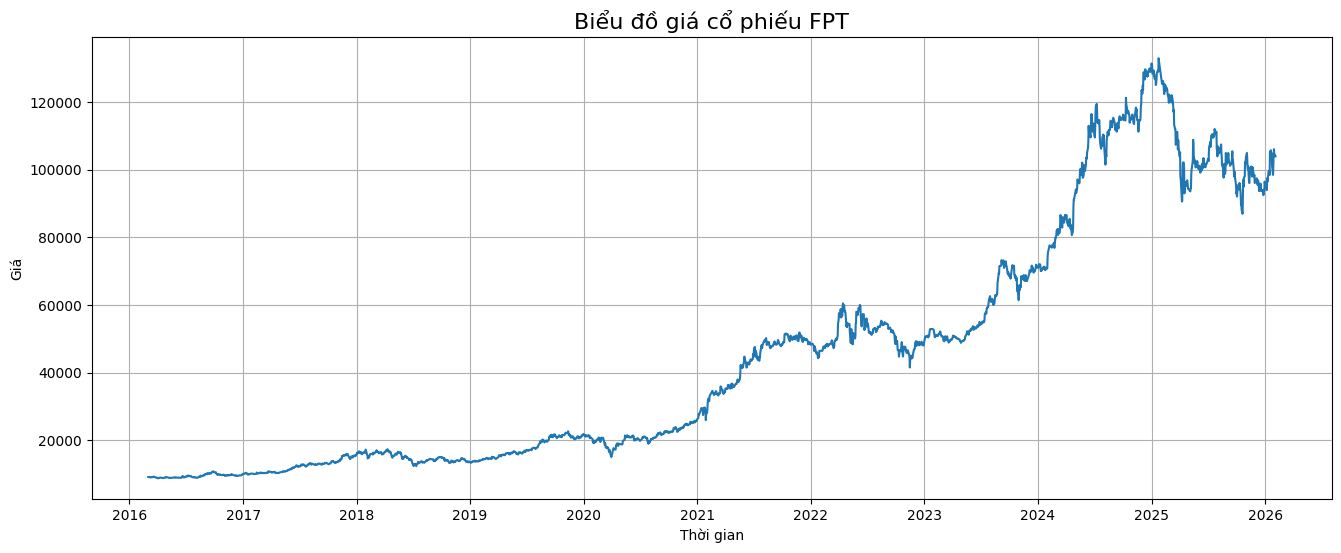

In [ ]:
# 11. Trực quan dữ liệu cột Price
for key, df in stock.items():

    plt.figure(figsize=(16,6))

    plt.plot(df.index, df['Price'])

    plt.title(f'Biểu đồ giá cổ phiếu {key}', fontsize=16)
    plt.xlabel('Thời gian')
    plt.ylabel('Giá')
    plt.grid(True)

    plt.show()


In [ ]:
# 12. Sử dụng log price thay price để giảm thiểu tác động bất ngờ và tạo log return

for key, df in stock.items():

    # 1. Tạo Log Price
    df['LogPrice'] = np.log(df['Price'])

    # 2. Tạo Log Return
    df['LogReturn'] = df['LogPrice'].diff()

    # 3. Xoá dòng đầu bị NaN do diff
    df = df.dropna(subset=['LogReturn'])

    stock[key] = df

    print(f"\nLog Return của cổ phiếu {key}")
    print(df[['Price', 'LogPrice', 'LogReturn']].head())



Log Return của cổ phiếu FPT
              Price  LogPrice  LogReturn
Date                                    
2016-03-03 9,097.30      9.12       0.00
2016-03-04 9,134.60      9.12       0.00
2016-03-05 9,109.77      9.12      -0.00
2016-03-06 9,084.93      9.11      -0.00
2016-03-07 9,060.10      9.11      -0.00


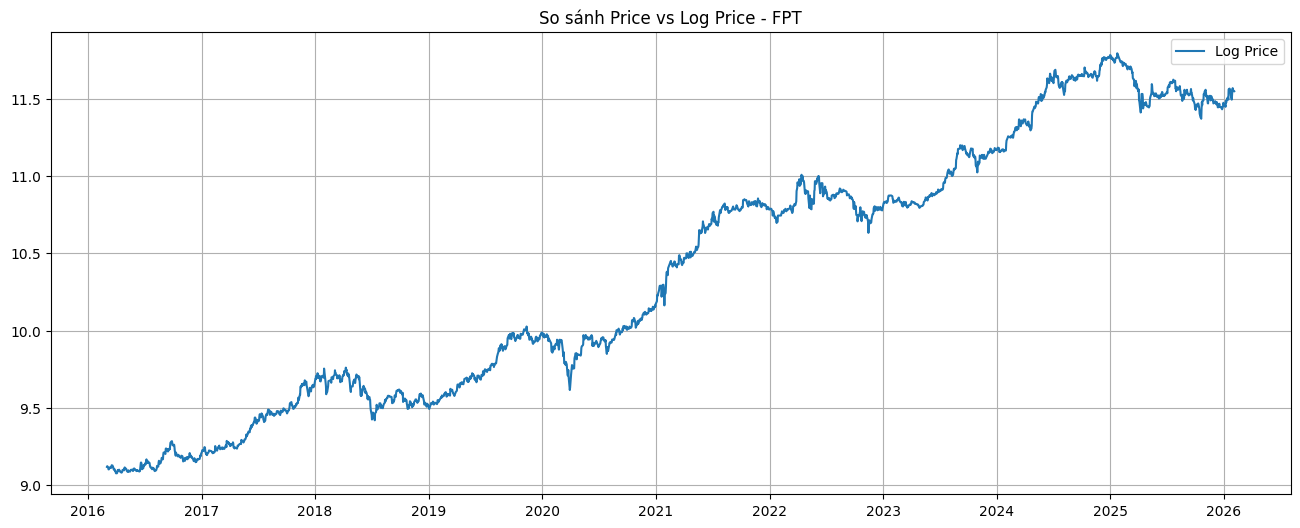

In [ ]:
# 13. Trực quan hóa log price
for key, df in stock.items():

    plt.figure(figsize=(16,6))

    plt.plot(df.index, df['LogPrice'], label='Log Price')

    plt.title(f'So sánh Price vs Log Price - {key}')
    plt.legend()
    plt.grid(True)

    plt.show()


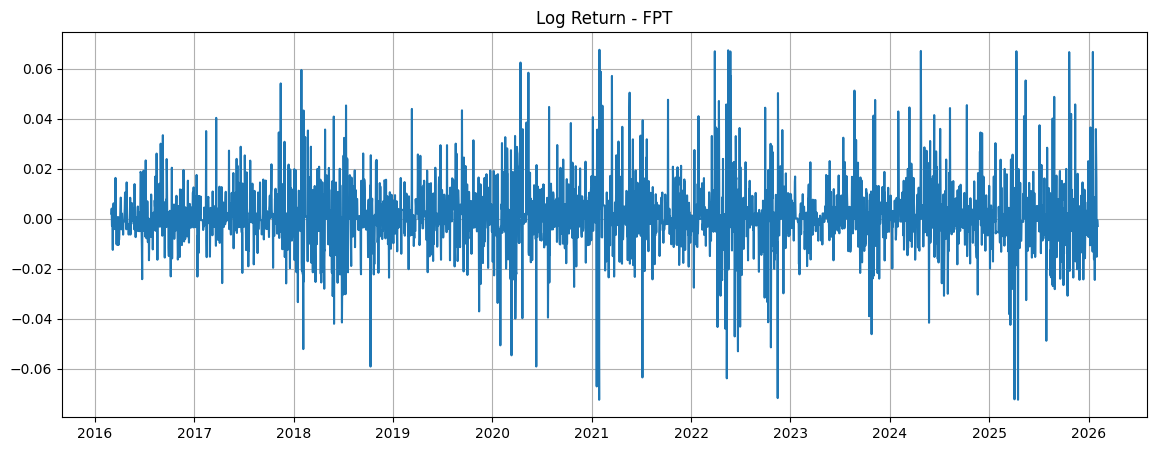

In [ ]:
# 14. Trực quan hóa log return
for key, df in stock.items():

    plt.figure(figsize=(14,5))

    plt.plot(df.index, df['LogReturn'])

    plt.title(f'Log Return - {key}')
    plt.grid(True)
    plt.show()

In [ ]:
# 15. Kiểm định adf
from statsmodels.tsa.stattools import adfuller

def adf_table(series, name, regression='c'):

    series = series.dropna()

    result = adfuller(
        series,
        regression=regression,
        autolag='AIC'
    )

    test_stat     = result[0]
    p_value       = result[1]
    lags_used     = result[2]
    n_obs         = result[3]
    critical_vals = result[4]

    stationary = "Yes" if p_value < 0.05 else "No"

    table = pd.DataFrame({
        name: [
            test_stat,
            p_value,
            lags_used,
            n_obs,
            critical_vals['1%'],
            critical_vals['5%'],
            critical_vals['10%'],
            stationary
        ]
    }, index=[
        "ADF test statistic",
        "p-value",
        "Lags used",
        "Observations",
        "Critical value (1%)",
        "Critical value (5%)",
        "Critical value (10%)",
        "Stationary (5%)"
    ])

    return table


In [ ]:
adf_table(df['Price'], 'Price', regression='ct')


,Price
ADF test statistic,-2.00
p-value,0.60
Lags used,29
Observations,3595
Critical value (1%),-3.96
Critical value (5%),-3.41
Critical value (10%),-3.13
Stationary (5%),No


In [ ]:
adf_table(df['LogPrice'], 'LogPrice', regression='ct')


,LogPrice
ADF test statistic,-2.31
p-value,0.43
Lags used,2
Observations,3622
Critical value (1%),-3.96
Critical value (5%),-3.41
Critical value (10%),-3.13
Stationary (5%),No


In [ ]:
adf_table(df['LogReturn'], 'LogReturn', regression='c')


,LogReturn
ADF test statistic,-40.29
p-value,0.00
Lags used,1
Observations,3623
Critical value (1%),-3.43
Critical value (5%),-2.86
Critical value (10%),-2.57
Stationary (5%),Yes


##5. Mô Hình LSTM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint

In [ ]:
stock

{'FPT':                 Price  LogPrice  LogReturn
 Date                                      
 2016-03-03   9,097.30      9.12       0.00
 2016-03-04   9,134.60      9.12       0.00
 2016-03-05   9,109.77      9.12      -0.00
 2016-03-06   9,084.93      9.11      -0.00
 2016-03-07   9,060.10      9.11      -0.00
 ...               ...       ...        ...
 2026-01-30 104,500.00     11.56      -0.02
 2026-01-31 104,433.33     11.56      -0.00
 2026-02-01 104,366.67     11.56      -0.00
 2026-02-02 104,300.00     11.56      -0.00
 2026-02-03 104,000.00     11.55      -0.00
 
 [3625 rows x 3 columns]}

In [ ]:
df1 = stock['FPT'][['LogPrice']].copy() # Select 'LogPrice' as a DataFrame
df1.columns = ['Giá'] # Set the column name to 'Giá'
df1.head()

,Giá
Date,
2016-03-03,9.12
2016-03-04,9.12
2016-03-05,9.12
2016-03-06,9.11
2016-03-07,9.11


In [ ]:
data = df1.values

train_size = int(len(data) * 0.8)
train_data = data[:train_size]
test_data = data[train_size:]

In [ ]:
sc = MinMaxScaler(feature_range=(0,1))
sc_train = sc.fit_transform(train_data.reshape(-1, 1))
sc_test = sc.transform(test_data.reshape(-1, 1))

In [ ]:
lookback = 100

x_train, y_train = [], []

for i in range(lookback, len(sc_train)):
    x_train.append(sc_train[i-lookback:i, 0])
    y_train.append(sc_train[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
y_train = np.reshape(y_train, (y_train.shape[0], 1))

In [ ]:
model = Sequential()

model.add(LSTM(128, return_sequences=True, input_shape=(lookback,1)))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1))

model.compile(loss='mean_absolute_error', optimizer='adam')

In [ ]:
save_model = "best_lstm_model.keras"

checkpoint = ModelCheckpoint(
    save_model,
    monitor='loss',
    verbose=2,
    save_best_only=True,
    mode='auto'
)

model.fit(
    x_train,
    y_train,
    epochs=20,
    batch_size=32,
    verbose=2,
    callbacks=[checkpoint]
)

Epoch 1/20

Epoch 1: loss improved from inf to 0.07001, saving model to best_lstm_model.keras
88/88 - 27s - 304ms/step - loss: 0.0700
Epoch 2/20

Epoch 2: loss improved from 0.07001 to 0.04066, saving model to best_lstm_model.keras
88/88 - 14s - 160ms/step - loss: 0.0407
Epoch 3/20

Epoch 3: loss improved from 0.04066 to 0.03644, saving model to best_lstm_model.keras
88/88 - 14s - 159ms/step - loss: 0.0364
Epoch 4/20

Epoch 4: loss improved from 0.03644 to 0.03643, saving model to best_lstm_model.keras
88/88 - 14s - 164ms/step - loss: 0.0364
Epoch 5/20

Epoch 5: loss improved from 0.03643 to 0.03335, saving model to best_lstm_model.keras
88/88 - 14s - 163ms/step - loss: 0.0333
Epoch 6/20

Epoch 6: loss improved from 0.03335 to 0.03139, saving model to best_lstm_model.keras
88/88 - 22s - 248ms/step - loss: 0.0314
Epoch 7/20

Epoch 7: loss did not improve from 0.03139
88/88 - 15s - 167ms/step - loss: 0.0339
Epoch 8/20

Epoch 8: loss did not improve from 0.03139
88/88 - 15s - 172ms/step -

In [ ]:
final_model = load_model(save_model)

y_train_predict = final_model.predict(x_train)

y_train_predict = sc.inverse_transform(y_train_predict)
y_train_real = sc.inverse_transform(y_train)

88/88 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step


In [ ]:
# Nối phần cuối train vào test để đủ lookback
full_test = np.concatenate((sc_train[-lookback:], sc_test), axis=0)

x_test = []

for i in range(lookback, len(full_test)):
    x_test.append(full_test[i-lookback:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], lookback, 1))

y_test_predict = final_model.predict(x_test)
y_test_predict = sc.inverse_transform(y_test_predict)

y_test_real = test_data

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


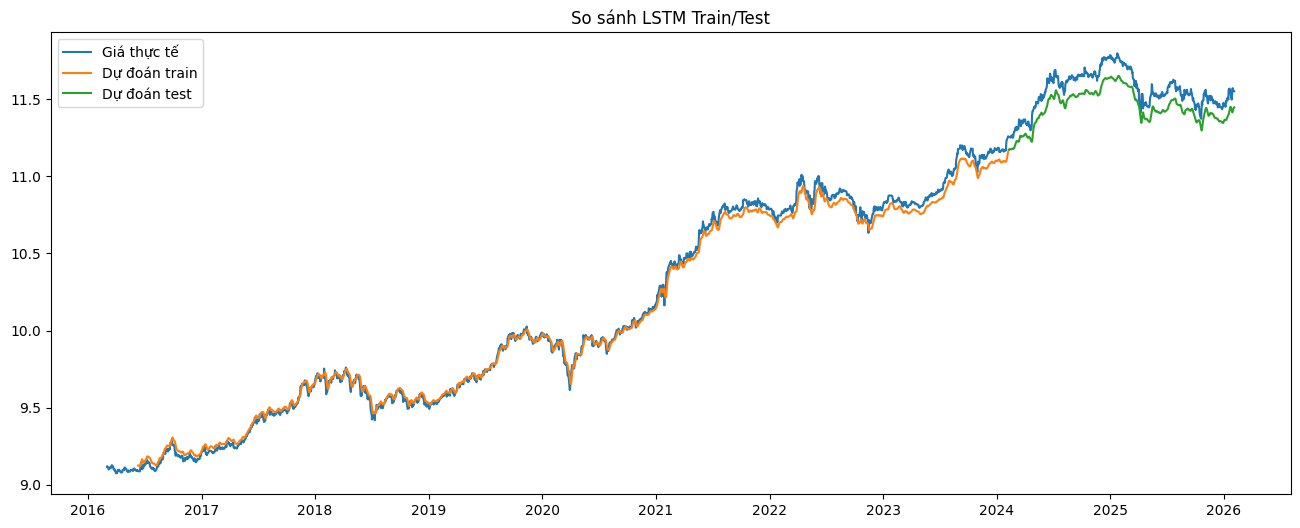

In [ ]:
train_plot = df1.iloc[lookback:train_size].copy()
train_plot['Dự đoán'] = y_train_predict

test_plot = df1.iloc[train_size:].copy()
test_plot['Dự đoán'] = y_test_predict

plt.figure(figsize=(16,6))

plt.plot(df1.index, df1['Giá'], label='Giá thực tế')
plt.plot(train_plot.index, train_plot['Dự đoán'], label='Dự đoán train')
plt.plot(test_plot.index, test_plot['Dự đoán'], label='Dự đoán test')

plt.legend()
plt.title("So sánh LSTM Train/Test")
plt.show()

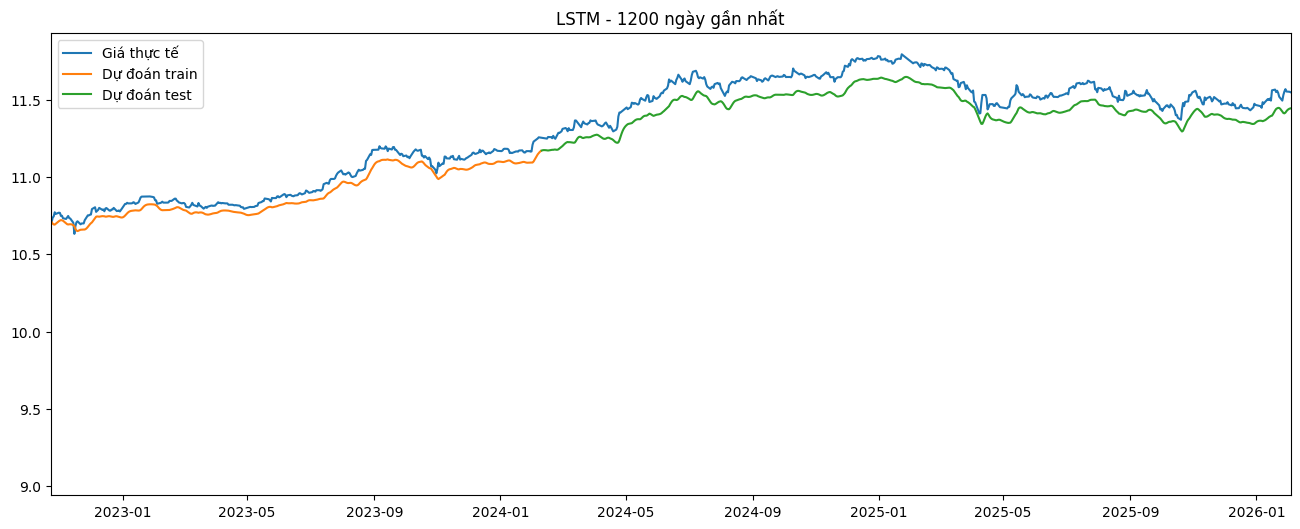

In [ ]:
train_plot = df1.iloc[lookback:train_size].copy()
train_plot['Dự đoán'] = y_train_predict

test_plot = df1.iloc[train_size:].copy()
test_plot['Dự đoán'] = y_test_predict

plt.figure(figsize=(16,6))

plt.plot(df1.index, df1['Giá'], label='Giá thực tế')
plt.plot(train_plot.index, train_plot['Dự đoán'], label='Dự đoán train')
plt.plot(test_plot.index, test_plot['Dự đoán'], label='Dự đoán test')

# ===== Zoom 1200 ngày gần nhất =====
plt.xlim(df1.index[-1200], df1.index[-1])

plt.legend()
plt.title("LSTM - 1200 ngày gần nhất")
plt.show()

##6. Huấn luyện model XGBoost dựa trên phần dư để tạo kiến trúc mô hình lai và dự báo 10 ngày tiếp theo

Số lượng residuals train: 2800
Số lượng residuals test: 725
Shape X_train_xgb: (2790, 10)
Shape y_train_xgb: (2790,)
Shape X_test_xgb : (715, 10)
Shape y_test_xgb : (715,)
[0]	validation_0-rmse:0.03596	validation_1-rmse:0.09404
[50]	validation_0-rmse:0.01187	validation_1-rmse:0.02779
[100]	validation_0-rmse:0.01063	validation_1-rmse:0.02301
[150]	validation_0-rmse:0.01006	validation_1-rmse:0.02234
[199]	validation_0-rmse:0.00961	validation_1-rmse:0.02204
Huấn luyện XGBoost hoàn tất.

Số lượng dự báo hybrid: 715

So sánh hiệu suất mô hình:
      LSTM  LSTM + XGBoost
MAE   0.11            0.02
MSE   0.01            0.00
RMSE  0.11            0.02
R2    0.12            0.97


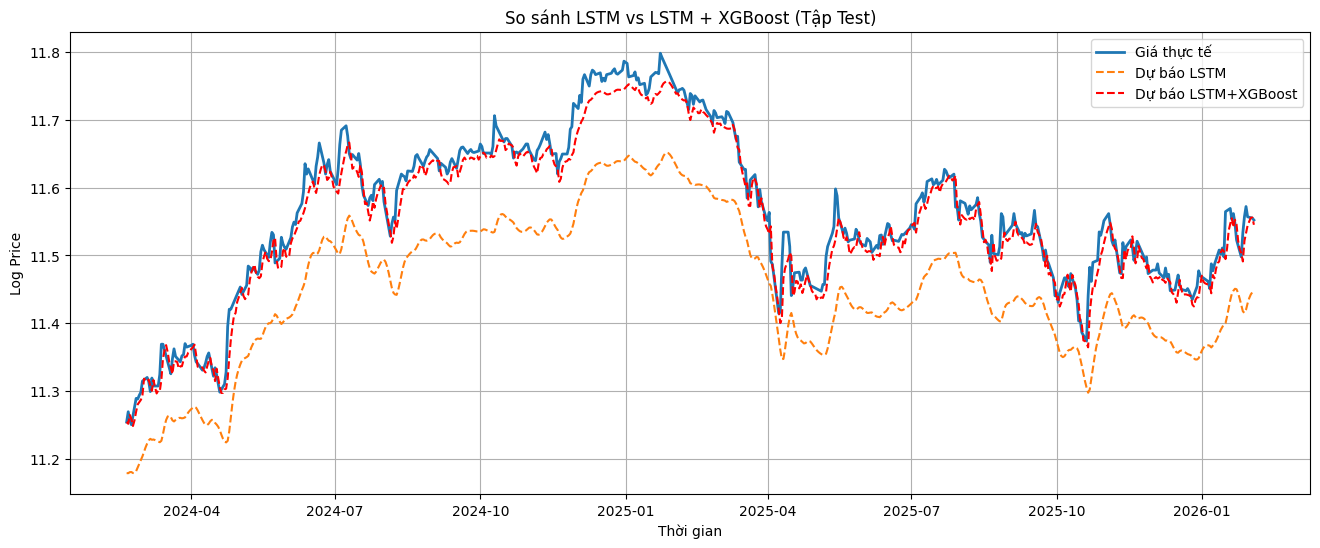

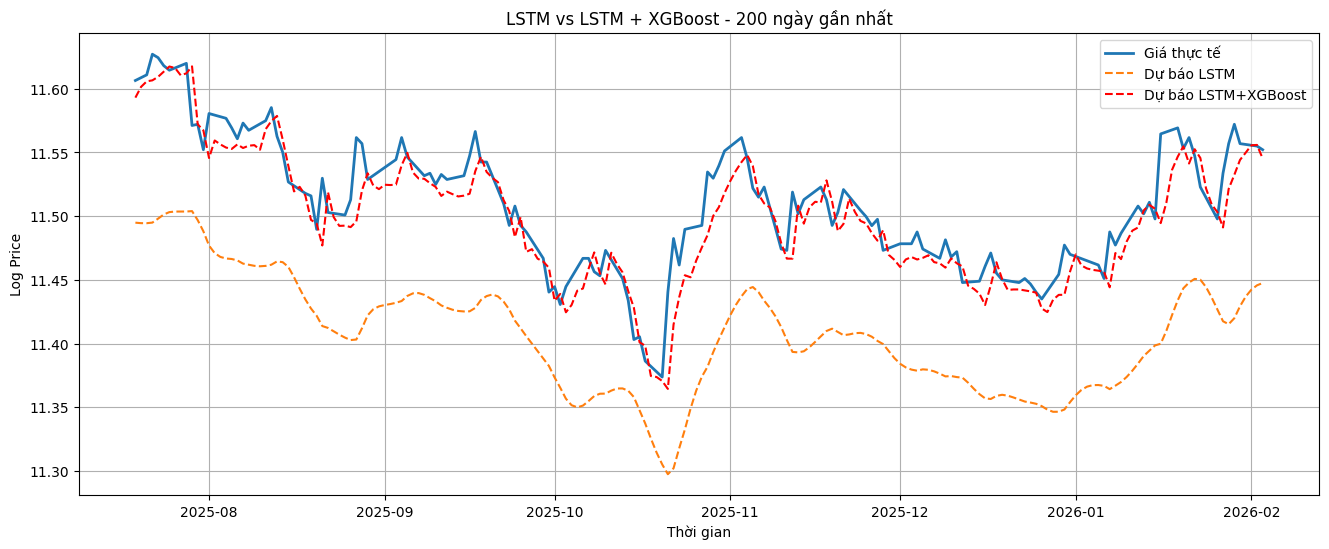

Ngày 1: 2026-02-04 → LogPrice dự báo: 11.5403 | Price dự báo: 102,779.50
Ngày 2: 2026-02-05 → LogPrice dự báo: 11.5180 | Price dự báo: 100,506.50
Ngày 3: 2026-02-06 → LogPrice dự báo: 11.4865 | Price dự báo: 97,390.92
Ngày 4: 2026-02-09 → LogPrice dự báo: 11.4578 | Price dự báo: 94,638.39
Ngày 5: 2026-02-10 → LogPrice dự báo: 11.4317 | Price dự báo: 92,197.99
Ngày 6: 2026-02-11 → LogPrice dự báo: 11.4025 | Price dự báo: 89,541.73
Ngày 7: 2026-02-12 → LogPrice dự báo: 11.3716 | Price dự báo: 86,824.03
Ngày 8: 2026-02-13 → LogPrice dự báo: 11.3506 | Price dự báo: 85,017.77
Ngày 9: 2026-02-16 → LogPrice dự báo: 11.3287 | Price dự báo: 83,175.96
Ngày 10: 2026-02-17 → LogPrice dự báo: 11.3053 | Price dự báo: 81,252.17

Bảng kết quả dự báo:
            LSTM_Pred  XGB_Correction  Final_Forecast  Price_Forecast
Date                                                                 
2026-02-04      11.45            0.09           11.54      102,779.50
2026-02-05      11.43            0.09        

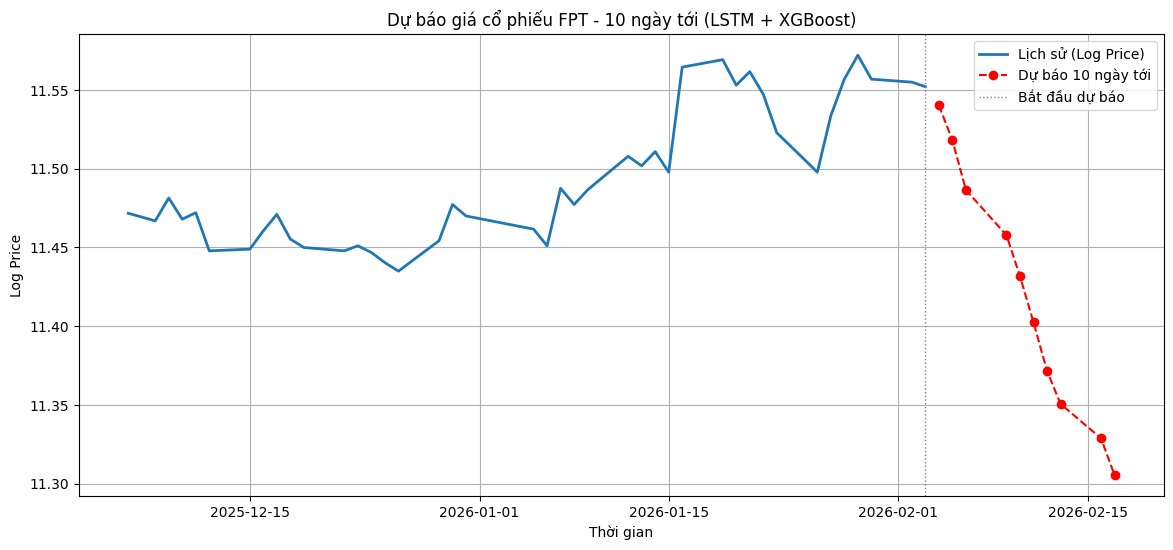

In [ ]:
"""XGBoost - Dự báo phần dư phi tuyến tính"""

import xgboost as xgb

# ============================================================
# BƯỚC 1: CHUẨN BỊ DỮ LIỆU
# Tư tưởng: XGBoost học phần phi tuyến mà LSTM không nắm bắt được
# Final = LSTM_pred + XGB_residual
# ============================================================

# Lấy residuals từ kết quả LSTM
# train residuals
train_residuals = y_train_real.flatten() - y_train_predict.flatten()

# test residuals
test_residuals = y_test_real.flatten() - y_test_predict.flatten()

print(f"Số lượng residuals train: {len(train_residuals)}")
print(f"Số lượng residuals test: {len(test_residuals)}")

# ============================================================
# BƯỚC 2: TẠO SLIDING WINDOW FEATURES TỪ RESIDUALS
# Dùng window_size ngày sai số quá khứ để dự đoán sai số hiện tại
# ============================================================

def create_window_features(residuals, window_size=10):
    """
    Tạo đặc trưng sliding window từ chuỗi residuals.
    Input : Mảng 1D residuals
    Output: X shape (n - window_size, window_size), y shape (n - window_size,)
    """
    X, y = [], []

    vals = residuals.flatten() if isinstance(residuals, np.ndarray) else np.array(residuals)

    for i in range(len(vals) - window_size):
        X.append(vals[i : i + window_size])
        y.append(vals[i + window_size])

    return np.array(X), np.array(y)

window_size = 10

X_train_xgb, y_train_xgb = create_window_features(train_residuals, window_size)
X_test_xgb,  y_test_xgb  = create_window_features(test_residuals,  window_size)

print(f"Shape X_train_xgb: {X_train_xgb.shape}")
print(f"Shape y_train_xgb: {y_train_xgb.shape}")
print(f"Shape X_test_xgb : {X_test_xgb.shape}")
print(f"Shape y_test_xgb : {y_test_xgb.shape}")

# ============================================================
# BƯỚC 3: HUẤN LUYỆN XGBOOST TRÊN RESIDUALS
# ============================================================

xgb_model = xgb.XGBRegressor(
    objective     = 'reg:squarederror',
    n_estimators  = 200,
    learning_rate = 0.05,
    max_depth     = 4,
    subsample     = 0.8,
    colsample_bytree = 0.8,
    random_state  = 42,
    verbosity     = 1
)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb,
    eval_set      = [(X_train_xgb, y_train_xgb), (X_test_xgb, y_test_xgb)],
    verbose       = 50
)

print("Huấn luyện XGBoost hoàn tất.")

# ============================================================
# BƯỚC 4: DỰ BÁO RESIDUALS VÀ TỔNG HỢP KẾT QUẢ
# Final prediction = LSTM_pred + XGB_residual_pred
# ============================================================

# Dự báo residuals trên tập test
xgb_residual_pred = xgb_model.predict(X_test_xgb)

# Căn chỉnh index: do window_size, XGBoost bỏ window_size dòng đầu
lstm_test_aligned  = y_test_predict.flatten()[window_size:]
actual_test_aligned = y_test_real.flatten()[window_size:]

# Tổng hợp
hybrid_pred = lstm_test_aligned + xgb_residual_pred

print(f"\nSố lượng dự báo hybrid: {len(hybrid_pred)}")

# ============================================================
# BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH
# ============================================================

def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    result = pd.DataFrame({
        model_name: [mae, mse, rmse, r2]
    }, index=['MAE', 'MSE', 'RMSE', 'R2'])

    return result

metrics_lstm   = evaluate_model(actual_test_aligned, lstm_test_aligned,  'LSTM')
metrics_hybrid = evaluate_model(actual_test_aligned, hybrid_pred,         'LSTM + XGBoost')

print("\nSo sánh hiệu suất mô hình:")
print(pd.concat([metrics_lstm, metrics_hybrid], axis=1))

# ============================================================
# BƯỚC 6: TRỰC QUAN HÓA KẾT QUẢ
# ============================================================

# Lấy index tương ứng
test_index_aligned = df1.iloc[train_size:].index[window_size:]

plt.figure(figsize=(16, 6))

plt.plot(test_index_aligned, actual_test_aligned,  label='Giá thực tế',       linewidth=2)
plt.plot(test_index_aligned, lstm_test_aligned,    label='Dự báo LSTM',        linestyle='--')
plt.plot(test_index_aligned, hybrid_pred,          label='Dự báo LSTM+XGBoost',linestyle='--', color='red')

plt.title('So sánh LSTM vs LSTM + XGBoost (Tập Test)')
plt.xlabel('Thời gian')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True)
plt.show()

# Zoom 200 ngày gần nhất
plt.figure(figsize=(16, 6))

plt.plot(test_index_aligned[-200:], actual_test_aligned[-200:],  label='Giá thực tế',        linewidth=2)
plt.plot(test_index_aligned[-200:], lstm_test_aligned[-200:],    label='Dự báo LSTM',         linestyle='--')
plt.plot(test_index_aligned[-200:], hybrid_pred[-200:],          label='Dự báo LSTM+XGBoost', linestyle='--', color='red')

plt.title('LSTM vs LSTM + XGBoost - 200 ngày gần nhất')
plt.xlabel('Thời gian')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# BƯỚC 7: DỰ BÁO TƯƠNG LAI (RECURSIVE FORECASTING)
# ============================================================

from pandas.tseries.offsets import BusinessDay

def forecast_hybrid_multiday(n_days, lstm_model, xgb_model, df_logprice, sc, lookback=100, window_size=10):
    """
    Dự báo đệ quy n ngày tương lai bằng mô hình lai LSTM + XGBoost.
    Mỗi bước: LSTM dự báo LogPrice → XGBoost hiệu chỉnh sai số → cộng tổng
    """

    # Lấy lịch sử LogPrice làm seed
    history_scaled = sc.transform(df_logprice.values.reshape(-1, 1)).flatten().tolist()

    # Lấy residuals gần nhất làm seed cho XGBoost
    recent_residuals = list(test_residuals.flatten()[-window_size:])

    forecast_results = []

    for i in range(n_days):

        # --- LSTM dự báo 1 bước ---
        lstm_input = np.array(history_scaled[-lookback:]).reshape(1, lookback, 1)
        lstm_pred_scaled = lstm_model.predict(lstm_input, verbose=0)[0][0]
        lstm_pred = sc.inverse_transform([[lstm_pred_scaled]])[0][0]

        # --- XGBoost hiệu chỉnh residual ---
        xgb_input = np.array(recent_residuals[-window_size:]).reshape(1, -1)
        xgb_correction = xgb_model.predict(xgb_input)[0]

        # --- Tổng hợp ---
        final_pred = lstm_pred + xgb_correction

        # --- Xác định ngày giao dịch tiếp theo ---
        if len(forecast_results) == 0:
            last_date = df_logprice.index[-1]
        else:
            last_date = forecast_results[-1]['Date']

        next_date = last_date + BusinessDay(1)

        forecast_results.append({
            'Date'            : next_date,
            'LSTM_Pred'       : lstm_pred,
            'XGB_Correction'  : xgb_correction,
            'Final_Forecast'  : final_pred
        })

        # --- Cập nhật lịch sử cho bước tiếp theo ---
        history_scaled.append(lstm_pred_scaled)
        recent_residuals.append(xgb_correction)

        print(f"Ngày {i+1}: {next_date.date()} → LogPrice dự báo: {final_pred:.4f} | Price dự báo: {np.exp(final_pred):,.2f}")

    forecast_df = pd.DataFrame(forecast_results)
    forecast_df.set_index('Date', inplace=True)

    return forecast_df

days_to_predict = 10

df_future = forecast_hybrid_multiday(
    n_days      = days_to_predict,
    lstm_model  = final_model,
    xgb_model   = xgb_model,
    df_logprice = df1['Giá'],
    sc          = sc,
    lookback    = lookback,
    window_size = window_size
)

# Chuyển LogPrice về Price thực tế
df_future['Price_Forecast'] = np.exp(df_future['Final_Forecast'])

print("\nBảng kết quả dự báo:")
print(df_future)

# ============================================================
# BƯỚC 8: TRỰC QUAN HÓA DỰ BÁO TƯƠNG LAI
# ============================================================

plt.figure(figsize=(14, 6))

last_real = df1['Giá'].iloc[-60:]
plt.plot(last_real.index, last_real.values, label='Lịch sử (Log Price)', linewidth=2)

plt.plot(df_future.index, df_future['Final_Forecast'],
         label=f'Dự báo {days_to_predict} ngày tới',
         color='red', linestyle='--', marker='o')

plt.axvline(x=df1.index[-1], color='gray', linestyle=':', linewidth=1, label='Bắt đầu dự báo')

plt.title(f'Dự báo giá cổ phiếu FPT - {days_to_predict} ngày tới (LSTM + XGBoost)')
plt.xlabel('Thời gian')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True)
plt.show()

Residuals train - mean: 0.014806 | std: 0.037626
Residuals test  - mean: 0.109473 | std: 0.024363
Kích thước đầu vào X cho XGBoost: (2790, 10)
Kích thước nhãn y cho XGBoost   : (2790,)
Huấn luyện XGBoost hoàn tất.
Ngày giao dịch gần nhất : 2026-02-03
LogPrice gần nhất       : 11.5521
Price gần nhất          : 104,000.00

Dự báo cho ngày giao dịch tiếp theo:
1. Dự báo LSTM              : 11.4478  → Price: 93,697.96
2. Hiệu chỉnh XGBoost       : 0.093391
3. LogPrice dự báo tổng hợp : 11.5412  → Price: 102,870.19
Ngày 1: 2026-02-04 -> LogPrice: 11.5412 | Price: 102,870.19
Ngày 2: 2026-02-05 -> LogPrice: 11.5347 | Price: 102,203.96
Ngày 3: 2026-02-06 -> LogPrice: 11.5192 | Price: 100,629.91
Ngày 4: 2026-02-09 -> LogPrice: 11.5129 | Price: 100,000.90
Ngày 5: 2026-02-10 -> LogPrice: 11.5054 | Price: 99,250.72
Ngày 6: 2026-02-11 -> LogPrice: 11.4985 | Price: 98,564.34
Ngày 7: 2026-02-12 -> LogPrice: 11.4813 | Price: 96,885.73
Ngày 8: 2026-02-13 -> LogPrice: 11.4730 | Price: 96,090.18
Ngày 9: 

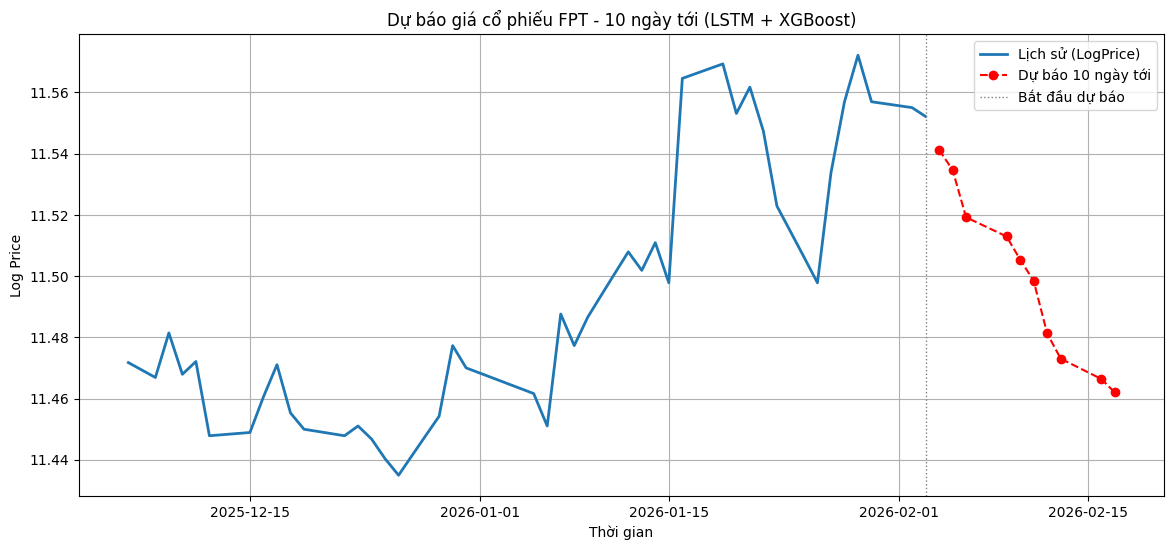

In [ ]:
"""XGBoost - Học phần dư phi tuyến từ LSTM để tạo mô hình lai LSTM + XGBoost"""

import xgboost as xgb
from pandas.tseries.offsets import BusinessDay

# ============================================================
# BƯỚC 1: TÍNH RESIDUALS TỪ KẾT QUẢ LSTM
# Residual = Giá thực - Giá LSTM dự báo (không gian LogPrice)
# ============================================================

# Residuals tập train (đã inverse_transform ở phần LSTM)
train_residuals = y_train_real.flatten() - y_train_predict.flatten()

# Residuals tập test
test_residuals = y_test_real.flatten() - y_test_predict.flatten()

print(f"Residuals train - mean: {train_residuals.mean():.6f} | std: {train_residuals.std():.6f}")
print(f"Residuals test  - mean: {test_residuals.mean():.6f} | std: {test_residuals.std():.6f}")

# ============================================================
# BƯỚC 2: TẠO SLIDING WINDOW FEATURES TỪ RESIDUALS
# Dùng window_size ngày sai số quá khứ để dự đoán sai số hôm nay
# ============================================================

def create_window_features(residuals, window_size=10):
    """
    Hàm tạo đặc trưng: Dùng n giá trị quá khứ để dự đoán giá trị hiện tại
    Input : Chuỗi residuals (numpy array hoặc pandas Series)
    Output: X (Ma trận đặc trưng), y (Nhãn mục tiêu)
    """
    X, y = [], []

    # Chuyển về numpy array
    vals = residuals.values if isinstance(residuals, pd.Series) else residuals.flatten()

    for i in range(len(vals) - window_size):
        # Đặc trưng: [e_t-10, ..., e_t-1]
        X.append(vals[i : i + window_size])
        # Mục tiêu: e_t
        y.append(vals[i + window_size])

    return np.array(X), np.array(y)

window_size = 10  # Dùng 10 ngày sai số quá khứ để đoán sai số hôm nay

X_xgb, y_xgb = create_window_features(train_residuals, window_size)

print(f"Kích thước đầu vào X cho XGBoost: {X_xgb.shape}")
print(f"Kích thước nhãn y cho XGBoost   : {y_xgb.shape}")

# ============================================================
# BƯỚC 3: HUẤN LUYỆN XGBOOST TRÊN RESIDUALS
# ============================================================

xgb_reg = xgb.XGBRegressor(
    objective        = 'reg:squarederror',
    n_estimators     = 100,   # Số lượng cây
    learning_rate    = 0.1,   # Tốc độ học
    max_depth        = 5,     # Độ sâu của cây (tránh overfitting)
    random_state     = 42
)

# Train mô hình để học quy luật của sai số
xgb_reg.fit(X_xgb, y_xgb)

print("Huấn luyện XGBoost hoàn tất.")

# ============================================================
# BƯỚC 4: DỰ BÁO 1 BƯỚC (T+1)
# ============================================================

def forecast_next_day(lstm_model, xgb_model, history_logprice, sc, lookback=100, window_size=10):
    """
    Hàm dự báo T+1 cho mô hình lai LSTM + XGBoost.
    Args:
    - lstm_model     : Model LSTM đã train
    - xgb_model      : Model XGBoost đã train trên residuals
    - history_logprice: Pandas Series LogPrice lịch sử
    - sc             : Scaler đã fit trên tập train
    - lookback       : Số ngày LSTM nhìn lại
    - window_size    : Số ngày residuals quá khứ XGBoost dùng
    Returns:
    - final_pred     : Giá dự báo tổng hợp (LogPrice)
    - lstm_pred      : Phần dự báo tuyến tính từ LSTM
    - xgb_correction : Phần hiệu chỉnh phi tuyến từ XGBoost
    """

    # --- LSTM dự báo 1 bước ---
    # Lấy lookback ngày cuối, scale, reshape về (1, lookback, 1)
    recent_scaled = sc.transform(
        history_logprice.values[-lookback:].reshape(-1, 1)
    )
    lstm_input = recent_scaled.reshape(1, lookback, 1)

    lstm_pred_scaled = lstm_model.predict(lstm_input, verbose=0)[0][0]
    lstm_pred = sc.inverse_transform([[lstm_pred_scaled]])[0][0]

    # --- Tính residuals gần nhất làm input cho XGBoost ---
    # LSTM dự báo in-sample trên window_size ngày cuối
    recent_actuals = history_logprice.values[-window_size:]

    lstm_insample_preds = []
    for j in range(window_size):
        # Mỗi bước lấy đúng lookback ngày trước điểm cần dự báo
        start = len(history_logprice) - window_size + j - lookback
        end   = len(history_logprice) - window_size + j
        segment = sc.transform(
            history_logprice.values[start:end].reshape(-1, 1)
        ).reshape(1, lookback, 1)
        p_scaled = lstm_model.predict(segment, verbose=0)[0][0]
        lstm_insample_preds.append(sc.inverse_transform([[p_scaled]])[0][0])

    lstm_insample_preds = np.array(lstm_insample_preds)
    recent_residuals = recent_actuals - lstm_insample_preds

    # --- XGBoost hiệu chỉnh residual ---
    xgb_input      = recent_residuals.reshape(1, -1)
    xgb_correction = xgb_model.predict(xgb_input)[0]

    # --- Tổng hợp ---
    final_pred = lstm_pred + xgb_correction

    return final_pred, lstm_pred, xgb_correction

# Kiểm tra dự báo T+1
print(f"Ngày giao dịch gần nhất : {df1.index[-1].date()}")
print(f"LogPrice gần nhất       : {df1['Giá'].iloc[-1]:.4f}")
print(f"Price gần nhất          : {np.exp(df1['Giá'].iloc[-1]):,.2f}")

final_price, lstm_part, xgb_part = forecast_next_day(
    lstm_model        = final_model,
    xgb_model         = xgb_reg,
    history_logprice  = df1['Giá'],
    sc                = sc,
    lookback          = lookback,
    window_size       = window_size
)

print(f"\nDự báo cho ngày giao dịch tiếp theo:")
print(f"1. Dự báo LSTM              : {lstm_part:.4f}  → Price: {np.exp(lstm_part):,.2f}")
print(f"2. Hiệu chỉnh XGBoost       : {xgb_part:.6f}")
print(f"3. LogPrice dự báo tổng hợp : {final_price:.4f}  → Price: {np.exp(final_price):,.2f}")

# ============================================================
# BƯỚC 5: DỰ BÁO ĐỆ QUY NHIỀU NGÀY
# ============================================================

def forecast_multi_days(n_days, lstm_model, xgb_model, df_logprice, sc, lookback=100, window_size=10):
    """
    Hàm dự báo đệ quy cho n ngày tương lai.
    Args:
    - n_days        : Số ngày muốn dự báo
    - lstm_model    : Model LSTM đã train
    - xgb_model     : Model XGBoost đã train
    - df_logprice   : Pandas Series LogPrice lịch sử
    - sc            : Scaler đã fit
    - lookback      : Số ngày LSTM nhìn lại
    - window_size   : Cửa sổ trượt của XGBoost
    Returns:
    - forecast_df   : DataFrame kết quả dự báo chi tiết theo ngày
    """
    history_series = df_logprice.copy()
    forecast_results = []

    for i in range(n_days):

        # Gọi hàm dự báo 1 bước
        final_pred, lstm_pred, xgb_correction = forecast_next_day(
            lstm_model       = lstm_model,
            xgb_model        = xgb_model,
            history_logprice = history_series,
            sc               = sc,
            lookback         = lookback,
            window_size      = window_size
        )

        # Xác định ngày làm việc tiếp theo
        last_date = history_series.index[-1]
        next_date = last_date + BusinessDay(1)

        # Lưu kết quả
        forecast_results.append({
            'Date'          : next_date,
            'LSTM_Pred'     : lstm_pred,
            'XGB_Correction': xgb_correction,
            'LogPrice_Forecast': final_pred,
            'Price_Forecast': np.exp(final_pred)
        })

        # Cập nhật lịch sử bằng giá dự báo để làm cơ sở cho bước kế tiếp
        new_row = pd.Series([final_pred], index=[next_date], name='Giá')
        history_series = pd.concat([history_series, new_row])

        print(f"Ngày {i+1}: {next_date.date()} -> LogPrice: {final_pred:.4f} | Price: {np.exp(final_pred):,.2f}")

    # Chuyển kết quả về DataFrame
    forecast_df = pd.DataFrame(forecast_results)
    forecast_df.set_index('Date', inplace=True)

    return forecast_df

days_to_predict = 10

df_future = forecast_multi_days(
    n_days       = days_to_predict,
    lstm_model   = final_model,
    xgb_model    = xgb_reg,
    df_logprice  = df1['Giá'],
    sc           = sc,
    lookback     = lookback,
    window_size  = window_size
)

# Hiển thị bảng kết quả
print("\nBảng chi tiết dự báo:")
print(df_future)

# ============================================================
# BƯỚC 6: TRỰC QUAN HÓA DỰ BÁO TƯƠNG LAI
# ============================================================

plt.figure(figsize=(14, 6))

# Vẽ 60 ngày lịch sử gần nhất
last_real_days = df1['Giá'].iloc[-60:]
plt.plot(last_real_days.index, last_real_days.values,
         label='Lịch sử (LogPrice)', linewidth=2)

# Vẽ phần dự báo tương lai
plt.plot(df_future.index, df_future['LogPrice_Forecast'],
         label=f'Dự báo {days_to_predict} ngày tới',
         color='red', linestyle='--', marker='o')

# Đường phân cách
plt.axvline(x=df1.index[-1], color='gray', linestyle=':', linewidth=1, label='Bắt đầu dự báo')

plt.title(f'Dự báo giá cổ phiếu FPT - {days_to_predict} ngày tới (LSTM + XGBoost)')
plt.xlabel('Thời gian')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True)
plt.show()


Bảng chi tiết dự báo (Price thực tế):
            Price_Forecast
Date                      
2026-02-04      102,870.19
2026-02-05      102,203.96
2026-02-06      100,629.91
2026-02-09      100,000.90
2026-02-10       99,250.72
2026-02-11       98,564.34
2026-02-12       96,885.73
2026-02-13       96,090.18
2026-02-16       95,455.70
2026-02-17       95,037.75


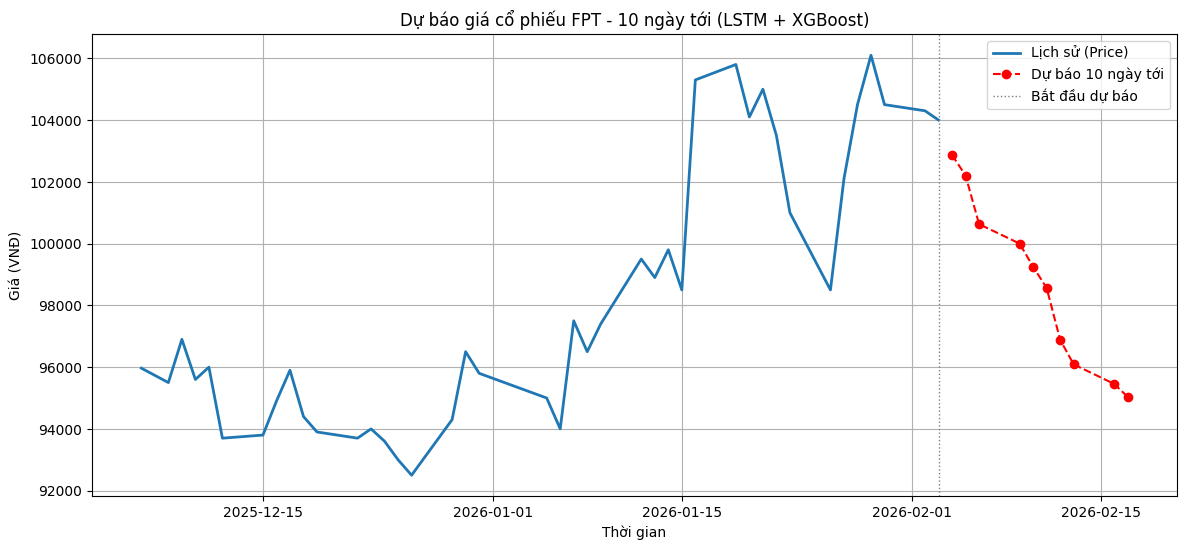

In [ ]:
# Chuyển đổi về Price thực tế để hiển thị
df_future['Price_Forecast'] = np.exp(df_future['LogPrice_Forecast'])

print("\nBảng chi tiết dự báo (Price thực tế):")
print(df_future[['Price_Forecast']])

# ============================================================
# TRỰC QUAN HÓA THEO PRICE THỰC TẾ
# ============================================================

plt.figure(figsize=(14, 6))

# Vẽ 60 ngày lịch sử gần nhất - chuyển về Price
last_real_days_price = np.exp(df1['Giá'].iloc[-60:])
plt.plot(last_real_days_price.index, last_real_days_price.values,
         label='Lịch sử (Price)', linewidth=2)

# Vẽ phần dự báo tương lai theo Price
plt.plot(df_future.index, df_future['Price_Forecast'],
         label=f'Dự báo {days_to_predict} ngày tới',
         color='red', linestyle='--', marker='o')

# Đường phân cách
plt.axvline(x=df1.index[-1], color='gray', linestyle=':', linewidth=1, label='Bắt đầu dự báo')

plt.title(f'Dự báo giá cổ phiếu FPT - {days_to_predict} ngày tới (LSTM + XGBoost)')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VNĐ)')
plt.legend()
plt.grid(True)
plt.show()

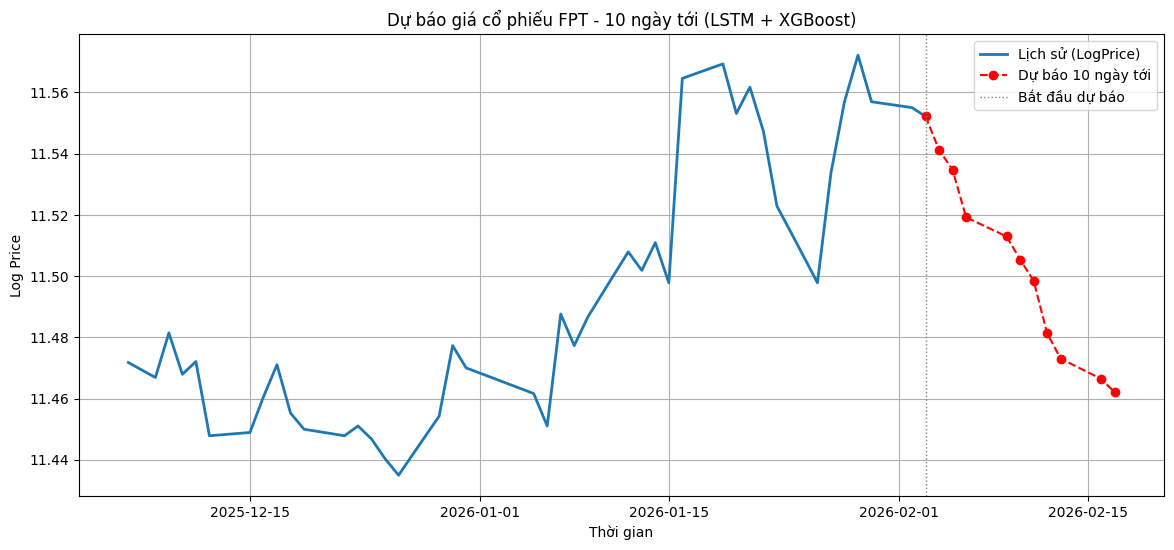

In [ ]:
plt.figure(figsize=(14, 6))

# Lịch sử 60 ngày - giữ LogPrice hoặc chuyển về Price tùy bạn
last_real_days = df1['Giá'].iloc[-60:]
plt.plot(last_real_days.index, last_real_days.values,
         label='Lịch sử (LogPrice)', linewidth=2)

# ===== NỐI 2 ĐƯỜNG: thêm điểm cuối lịch sử vào đầu chuỗi dự báo =====
bridge_index  = [last_real_days.index[-1]]  + list(df_future.index)
bridge_values = [last_real_days.values[-1]] + list(df_future['LogPrice_Forecast'])

plt.plot(bridge_index, bridge_values,
         label=f'Dự báo {days_to_predict} ngày tới',
         color='red', linestyle='--', marker='o')

plt.axvline(x=df1.index[-1], color='gray', linestyle=':', linewidth=1, label='Bắt đầu dự báo')

plt.title(f'Dự báo giá cổ phiếu FPT - {days_to_predict} ngày tới (LSTM + XGBoost)')
plt.xlabel('Thời gian')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True)
plt.show()

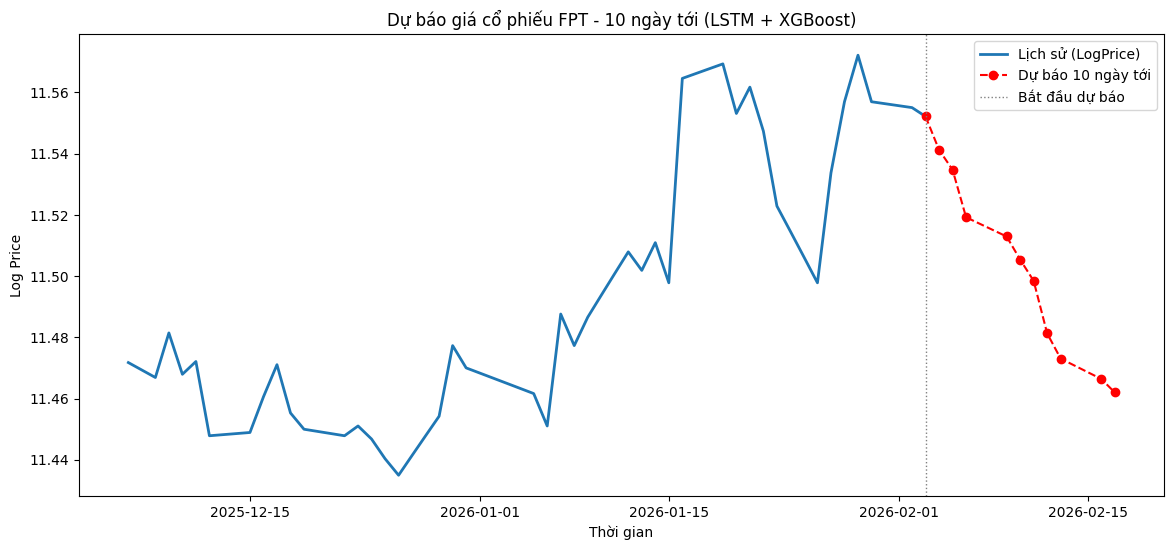

In [ ]:
plt.figure(figsize=(14, 6))

last_real_days = df1['Giá'].iloc[-60:]
plt.plot(last_real_days.index, last_real_days.values,
         label='Lịch sử (LogPrice)', linewidth=2)

bridge_index  = [last_real_days.index[-1]]  + list(df_future.index)
bridge_values = [last_real_days.values[-1]] + list(df_future['LogPrice_Forecast'])

plt.plot(bridge_index, bridge_values,
         label=f'Dự báo {days_to_predict} ngày tới',
         color='red', linestyle='--', marker='o')

plt.axvline(x=df1.index[-1], color='gray', linestyle=':', linewidth=1, label='Bắt đầu dự báo')

plt.title(f'Dự báo giá cổ phiếu FPT - {days_to_predict} ngày tới (LSTM + XGBoost)')
plt.xlabel('Thời gian')
plt.ylabel('Log Price')
plt.legend()
plt.show()

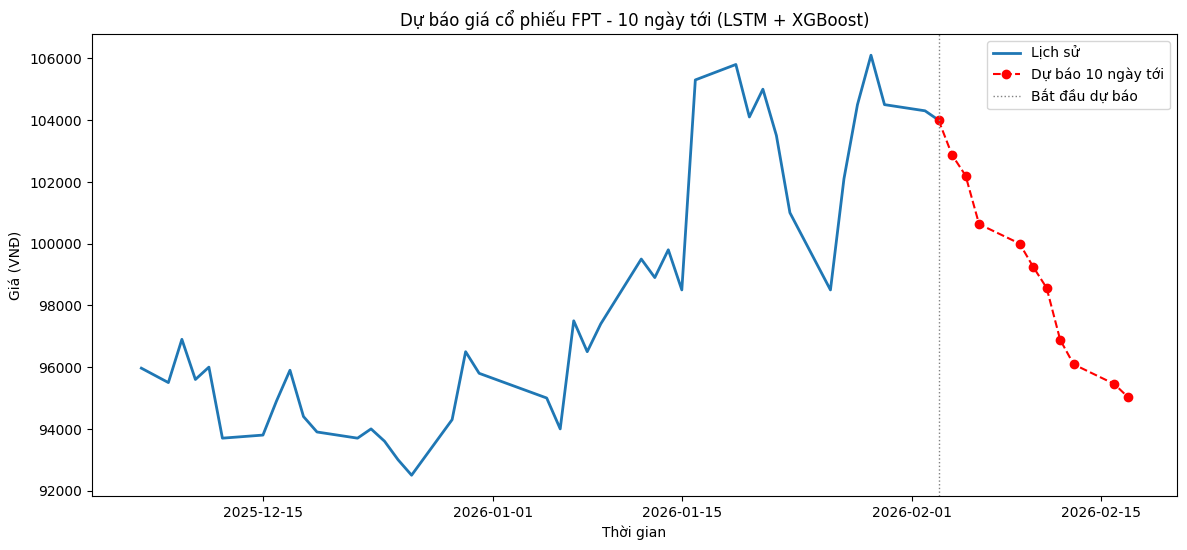

In [ ]:
plt.figure(figsize=(14, 6))

last_real_days = np.exp(df1['Giá'].iloc[-60:])
plt.plot(last_real_days.index, last_real_days.values,
         label='Lịch sử ', linewidth=2)

bridge_index  = [last_real_days.index[-1]]  + list(df_future.index)
bridge_values = [last_real_days.values[-1]] + list(df_future['Price_Forecast'])

plt.plot(bridge_index, bridge_values,
         label=f'Dự báo {days_to_predict} ngày tới',
         color='red', linestyle='--', marker='o')

plt.axvline(x=df1.index[-1], color='gray', linestyle=':', linewidth=1, label='Bắt đầu dự báo')

plt.title(f'Dự báo giá cổ phiếu FPT - {days_to_predict} ngày tới (LSTM + XGBoost)')
plt.xlabel('Thời gian')
plt.ylabel('Giá (VNĐ)')
plt.legend()
plt.show()

In [ ]:
print(df_future[['Price_Forecast']])

            Price_Forecast
Date                      
2026-02-04      102,870.19
2026-02-05      102,203.96
2026-02-06      100,629.91
2026-02-09      100,000.90
2026-02-10       99,250.72
2026-02-11       98,564.34
2026-02-12       96,885.73
2026-02-13       96,090.18
2026-02-16       95,455.70
2026-02-17       95,037.75


In [ ]:
df_future[['Price_Forecast']].style.format({'Price_Forecast': '{:,.2f}'})

,Price_Forecast
Date,
2026-02-04 00:00:00,"102,870.19"
2026-02-05 00:00:00,"102,203.96"
2026-02-06 00:00:00,"100,629.91"
2026-02-09 00:00:00,"100,000.90"
2026-02-10 00:00:00,"99,250.72"
2026-02-11 00:00:00,"98,564.34"
2026-02-12 00:00:00,"96,885.73"
2026-02-13 00:00:00,"96,090.18"
2026-02-16 00:00:00,"95,455.70"


In [ ]:
# ============================================================
# ĐÁNH GIÁ HIỆU SUẤT MÔ HÌNH
# ============================================================

def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)

    result = pd.DataFrame({
        model_name: [mae, mse, rmse, r2]
    }, index=['MAE', 'MSE', 'RMSE', 'R2'])

    return result

print("--- Đánh giá hiệu suất mô hình ---")

# ============================================================
# METRICS TRÊN TẬP TRAIN
# ============================================================

metrics_train = evaluate_model(
    y_train_real.flatten(),
    y_train_predict.flatten(),
    'LSTM (Train)'
)

print("\nMetrics trên tập Train:")
print(metrics_train.round(2))

# ============================================================
# METRICS TRÊN TẬP TEST — SO SÁNH LSTM VS LSTM+XGBOOST
# ============================================================

# Căn chỉnh index do XGBoost bỏ window_size dòng đầu
actual_aligned = y_test_real.flatten()[window_size:]
lstm_aligned   = y_test_predict.flatten()[window_size:]

# XGBoost dự báo residuals trên tập test
X_test_xgb, _ = create_window_features(test_residuals, window_size)
xgb_residual_test = xgb_reg.predict(X_test_xgb)

# Tổng hợp hybrid
hybrid_pred = lstm_aligned + xgb_residual_test

metrics_lstm   = evaluate_model(actual_aligned, lstm_aligned,  'LSTM (Test)')
metrics_hybrid = evaluate_model(actual_aligned, hybrid_pred,   'LSTM + XGBoost (Test)')

print("\nMetrics trên tập Test (So sánh LSTM và LSTM+XGBoost):")
print(pd.concat([metrics_lstm, metrics_hybrid], axis=1).round(2))

--- Đánh giá hiệu suất mô hình ---

Metrics trên tập Train:
      LSTM (Train)
MAE           0.03
MSE           0.00
RMSE          0.04
R2            1.00

Metrics trên tập Test (So sánh LSTM và LSTM+XGBoost):
      LSTM (Test)  LSTM + XGBoost (Test)
MAE          0.11                   0.01
MSE          0.01                   0.00
RMSE         0.11                   0.02
R2           0.12                   0.97
